# TIES-Merging — pipeline v5 (pulita, senza dataset_merged)

**Diagnosi (dai tuoi TEST A/B):** gli specialisti sono ottimi (star removal 40.6 dB,
restoration 39.2 dB), quindi il problema **non** sono i modelli né il codice: è il
**merge** (H1). Il motivo specifico: `theta0` da solo fa ~12 dB su star removal
(peggio dell'identità), cioè è una **base debole** — il merge deve *ricostruire*
quasi tutto il task vector, non solo combinarlo. Il TIES classico con media (`mean`)
divide il contributo di ogni task per il numero di task concordi, **diluendolo**
sotto la soglia utile. Da qui il cast verde e le stelle residue.

**Cosa cambia in v5:**
- **`merge_method`**: oltre a `mean` (TIES classico) ora ci sono `sum` (somma i task
  concordi → preserva l'ampiezza del singolo task) e `dropout_rescale` (trim + rescale
  1/keep_ratio, stile DARE). Con una base debole `sum` è spesso ciò che serve.
- **griglia più forte**: `keep_ratio` fino a 0.8 e `lambda` fino a 2.0 (con base
  debole servono valori più alti), più pesi **per-task** che enfatizzano star removal.
- **selezione** su retention media con `retention_min` come tie-break (non premia
  config che sacrificano del tutto un task).
- **zero `dataset_merged`**: rimosso ovunque, anche le funzioni non più usate.

**Struttura** (esegui in ordine): 1 architettura · 2 config · 3 funzioni merge ·
4 funzioni eval · 5 **grid search** · 6 visualizzazione.

Se dopo questa griglia la retention resta bassa (< ~0.5), significa che TIES su
questi 3 task ha un limite strutturale (i task vector interferiscono troppo): in
quel caso l'alternativa è un merge **solo di 2 task** alla volta, o abbandonare
TIES per un fine-tuning breve del modello fuso — ma provala prima, spesso `sum`
+ lambda alto recupera gran parte del gap.


In [22]:
"""
Architettura del DDPM condizionato (identica al notebook di training
image-restoration-con-theta0.ipynb, sezione "ARCHITETTURA INVARIATA").

Questo modulo va importato sia dagli script di training dei 3 modelli
specializzati, sia dallo script di TIES merging, così da garantire che
tutti i checkpoint (theta0 + i 3 fine-tuned) condividano ESATTAMENTE
la stessa architettura e quindi state_dict con le stesse chiavi/shape.
"""

import math
import torch
import torch.nn as nn
import torch.nn.functional as F


class SelfAttention(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.channels = channels
        self.mha = nn.MultiheadAttention(embed_dim=channels, num_heads=2, batch_first=True)
        self.ln = nn.LayerNorm(channels)
        self.ff_self = nn.Sequential(
            nn.LayerNorm(channels),
            nn.Linear(channels, channels),
            nn.GELU(),
            nn.Linear(channels, channels),
        )

    def forward(self, x):
        size = x.shape[-1]
        x_flat = x.reshape(-1, self.channels, size * size).transpose(1, 2)
        x_ln = self.ln(x_flat)
        attention_value, _ = self.mha(x_ln, x_ln, x_ln)
        attention_value = attention_value + x_flat
        attention_value = self.ff_self(attention_value) + attention_value
        return attention_value.transpose(1, 2).reshape(-1, self.channels, size, size)


class UNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim=32, num_groups=4):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.gn1 = nn.GroupNorm(num_groups, out_channels)
        self.act1 = nn.SiLU()

        self.time_mlp = nn.Linear(time_dim, out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.gn2 = nn.GroupNorm(num_groups, out_channels)
        self.act2 = nn.SiLU()

        self.residual_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()

    def forward(self, x, t_emb):
        h = self.act1(self.gn1(self.conv1(x)))
        time_proj = self.time_mlp(t_emb).unsqueeze(-1).unsqueeze(-1)
        h = h + time_proj
        h = self.act2(self.gn2(self.conv2(h)))
        return h + self.residual_conv(x)


class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings


class ImprovedUNet(nn.Module):
    def __init__(self, in_channels=3, cond_channels=3, base_channels=64):
        super().__init__()

        time_dim = base_channels * 4
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(base_channels),
            nn.Linear(base_channels, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim)
        )

        c = base_channels

        self.inc = UNetBlock(in_channels + cond_channels, c, time_dim)

        self.down1 = nn.Conv2d(c, c, kernel_size=4, stride=2, padding=1)
        self.enc1 = UNetBlock(c, c * 2, time_dim)

        self.down2 = nn.Conv2d(c * 2, c * 2, kernel_size=4, stride=2, padding=1)
        self.enc2 = UNetBlock(c * 2, c * 4, time_dim)

        self.down3 = nn.Conv2d(c * 4, c * 4, kernel_size=4, stride=2, padding=1)
        self.enc3 = UNetBlock(c * 4, c * 8, time_dim)
        self.attn3 = SelfAttention(c * 8)

        self.down4 = nn.Conv2d(c * 8, c * 8, kernel_size=4, stride=2, padding=1)

        self.bottleneck1 = UNetBlock(c * 8, c * 8, time_dim)
        self.attention = SelfAttention(c * 8)
        self.bottleneck2 = UNetBlock(c * 8, c * 8, time_dim)

        self.up1 = nn.ConvTranspose2d(c * 8, c * 8, kernel_size=4, stride=2, padding=1)
        self.dec1 = UNetBlock(c * 16, c * 4, time_dim)
        self.attn_up1 = SelfAttention(c * 4)

        self.up2 = nn.ConvTranspose2d(c * 4, c * 4, kernel_size=4, stride=2, padding=1)
        self.dec2 = UNetBlock(c * 8, c * 2, time_dim)

        self.up3 = nn.ConvTranspose2d(c * 2, c * 2, kernel_size=4, stride=2, padding=1)
        self.dec3 = UNetBlock(c * 4, c, time_dim)

        self.up4 = nn.ConvTranspose2d(c, c, kernel_size=4, stride=2, padding=1)
        self.dec4 = UNetBlock(c * 2, c, time_dim)

        self.out = nn.Conv2d(c, in_channels, kernel_size=3, padding=1)

    def forward(self, x_t, t, condition):
        x_input = torch.cat([x_t, condition], dim=1)
        t_emb = self.time_mlp(t.float())

        s1 = self.inc(x_input, t_emb)
        h = self.down1(s1)

        s2 = self.enc1(h, t_emb)
        h = self.down2(s2)

        s3 = self.enc2(h, t_emb)
        h = self.down3(s3)

        s4 = self.enc3(h, t_emb)
        s4 = self.attn3(s4)
        h = self.down4(s4)

        h = self.bottleneck1(h, t_emb)
        h = self.attention(h)
        h = self.bottleneck2(h, t_emb)

        h = self.up1(h)
        h = torch.cat([h, s4], dim=1)
        h = self.dec1(h, t_emb)
        h = self.attn_up1(h)

        h = self.up2(h)
        h = torch.cat([h, s3], dim=1)
        h = self.dec2(h, t_emb)

        h = self.up3(h)
        h = torch.cat([h, s2], dim=1)
        h = self.dec3(h, t_emb)

        h = self.up4(h)
        h = torch.cat([h, s1], dim=1)
        h = self.dec4(h, t_emb)

        return self.out(h)


def cosine_beta_schedule(timesteps, s=0.008):
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 1e-4, 0.9999)


class DDPMvPrediction(nn.Module):
    def __init__(self, network, n_steps=200, beta_start=1e-4, beta_end=0.02):
        super().__init__()
        self.network = network
        self.n_steps = n_steps

        beta = cosine_beta_schedule(n_steps)
        alpha = 1.0 - beta
        alpha_bar = torch.cumprod(alpha, dim=0)
        alpha_bar_prev = torch.cat([torch.tensor([1.0]), alpha_bar[:-1]])

        sqrt_alpha_bar = torch.sqrt(alpha_bar)
        sqrt_one_minus_alpha_bar = torch.sqrt(1.0 - alpha_bar)

        self.register_buffer('alpha_bar', alpha_bar)
        self.register_buffer('alpha_bar_prev', alpha_bar_prev)
        self.register_buffer('sqrt_alpha_bar', sqrt_alpha_bar)
        self.register_buffer('sqrt_one_minus_alpha_bar', sqrt_one_minus_alpha_bar)
        self.register_buffer('beta', beta)
        self.register_buffer('alpha', alpha)
        self.register_buffer('posterior_variance', beta * (1 - alpha_bar_prev) / (1 - alpha_bar))

    def forward_diffusion(self, x_0, t, noise):
        sqrt_alpha_bar_t = self.sqrt_alpha_bar[t].view(-1, 1, 1, 1)
        sqrt_one_minus_alpha_bar_t = self.sqrt_one_minus_alpha_bar[t].view(-1, 1, 1, 1)
        return sqrt_alpha_bar_t * x_0 + sqrt_one_minus_alpha_bar_t * noise

    def forward(self, x_0, condition):
        batch_size = x_0.shape[0]
        t = torch.randint(0, self.n_steps, (batch_size,), device=x_0.device)
        noise = torch.randn_like(x_0)

        x_t = self.forward_diffusion(x_0, t, noise)

        sqrt_alpha_bar_t = self.sqrt_alpha_bar[t].view(-1, 1, 1, 1)
        sqrt_one_minus_alpha_bar_t = self.sqrt_one_minus_alpha_bar[t].view(-1, 1, 1, 1)

        v_target = sqrt_alpha_bar_t * noise - sqrt_one_minus_alpha_bar_t * x_0
        predicted_v = self.network(x_t, t.float(), condition)

        loss = F.mse_loss(predicted_v, v_target)
        return loss

    @torch.no_grad()
    def sample(self, condition):
        self.network.eval()
        device = self.beta.device

        batch_size, channels, height, width = condition.shape
        x = torch.randn(batch_size, channels, height, width, device=device)

        for i in reversed(range(self.n_steps)):
            t = torch.full((batch_size,), i, dtype=torch.long, device=device)
            predicted_v = self.network(x, t.float(), condition)

            sqrt_alpha_bar_t = self.sqrt_alpha_bar[i]
            sqrt_one_minus_alpha_bar_t = self.sqrt_one_minus_alpha_bar[i]

            pred_x0 = (sqrt_alpha_bar_t * x) - (sqrt_one_minus_alpha_bar_t * predicted_v)
            pred_x0 = torch.clamp(pred_x0, -1.0, 1.0)

            beta_t = self.beta[i]
            alpha_bar_prev_t = self.alpha_bar_prev[i]
            alpha_bar_t = self.alpha_bar[i]
            alpha_t = self.alpha[i]

            mean = (beta_t * torch.sqrt(alpha_bar_prev_t) / (1.0 - alpha_bar_t)) * pred_x0 + \
                   ((1.0 - alpha_bar_prev_t) * torch.sqrt(alpha_t) / (1.0 - alpha_bar_t)) * x

            if i > 0:
                noise = torch.randn_like(x)
                sigma_t = torch.sqrt(self.posterior_variance[i])
                x = mean + sigma_t * noise
            else:
                x = mean

        self.network.train()
        return x


def build_model(n_steps=200, base_channels=64, in_channels=3, cond_channels=3, device="cuda"):
    """Factory di comodo: istanzia UNet + wrapper DDPM con gli stessi
    iperparametri usati in training, cosi' da poter caricare i checkpoint."""
    net = ImprovedUNet(in_channels=in_channels, cond_channels=cond_channels, base_channels=base_channels)
    model = DDPMvPrediction(net, n_steps=n_steps)
    return model.to(device)

In [23]:
# ==============================================================================
# CELLA 2 - CONFIGURAZIONE (l'unica cella che devi toccare)
# ==============================================================================
import sys, os, json, itertools, time, glob
from pathlib import Path
from typing import Dict, List, Sequence, Tuple, Optional
import numpy as np
import torch

# ----- checkpoint -----
PATH_THETA0      = "/kaggle/input/datasets/ilariadarchivio/theta0-pretrain/theta0.pth"
PATH_STAR        = "/kaggle/input/datasets/ilariadarchivio/epoch-100/ddpmvpred_epoch_100.pth"
PATH_RESTORATION = "/kaggle/input/datasets/ilariadarchivio/epoch-100/ddpmvpred_epoch_100_IR.pth"
PATH_SUPERRES    = "/kaggle/input/datasets/ilariadarchivio/epoch-100/ddpmvpred_epoch_100_SR.pth"
PATH_OUTPUT      = "/kaggle/working/ties.pth"
LOG_JSON         = "/kaggle/working/search_log.json"

# ----- dataset per la GRID SEARCH: i VALIDATION SPLIT usati nel training -----
# (chiavi 'val_input'/'val_target' dei manifest). Le 'roots' servono solo come
# fallback per risolvere i path assoluti se cambiano tra sessioni Kaggle.
# NB: star_removal e star_removal_uar condividono lo stesso manifest -> un solo
# validation set; le due root sono solo fallback per la risoluzione dei path.
# --- La search e la valutazione usano ESCLUSIVAMENTE i validation split
#     dei 3 task (nessun altro dataset). ---
EVAL_SOURCES = {
    "restoration": {
        "manifest": "/kaggle/input/datasets/ilariadarchivio/split-dataset/split_manifest_IR.json",
        "roots": ["/kaggle/input/datasets/phantasm04/image-restoration/dataset_ir"],
    },
    "super_resolution": {
        "manifest": "/kaggle/input/datasets/ilariadarchivio/split-dataset/split_manifest_SR.json",
        "roots": ["/kaggle/input/datasets/phantasm04/super-resolution/dataset_su"],
    },
    "star_removal": {
        "manifest": "/kaggle/input/datasets/ilariadarchivio/split-dataset/split_manifest.json",
        "roots": ["/kaggle/input/datasets/phantasm04/star-removal/dataset",
                   "/kaggle/input/datasets/phantasm04/star-removal-uar/dataset"],
    },
}

# ----- architettura / inferenza -----
N_STEPS       = 200
BASE_CHANNELS = 64
DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"
USE_EMA       = True

# ----- merge -----
TASKS = ["star_removal", "restoration", "super_resolution"]
TASK_PATHS = {"star_removal": PATH_STAR, "restoration": PATH_RESTORATION, "super_resolution": PATH_SUPERRES}

# --- GRIGLIA (ampliata per il caso "base theta0 debole", vedi diagnosi) ---
# merge_method: "sum" preserva l'ampiezza del task (spesso necessario qui),
#               "mean" e' il TIES classico, "dropout_rescale" e' via di mezzo.
MERGE_METHOD_GRID = ["sum"]#, "dropout_rescale", "mean"]
KEEP_RATIO_GRID   = [0.2, 0.5, 0.8]
LAMBDA_SCALE_GRID = [0.5, 0.8, 1.0, 1.3, 1.6]
# pesi PER-TASK provati in fase di merge. Danno piu' forza al task che theta0 non
# sa fare (star removal) e meno a quello gia' vicino all'identita' (super res).
TASK_LAMBDAS_GRID: List[Optional[Tuple[float, ...]]] = [
    None,                 # (1,1,1)
    #(1.0, 1.0, 0.5),      # de-pesa super_resolution
    #(1.0, 1.0, 0.0),      # esclude super_resolution
    #(1.3, 1.0, 0.5),      # enfatizza star_removal
]
TOP_K_FULL_EVAL = 5       # quante config passano dalla proxy v-loss al PSNR/SSIM

# ----- valutazione -----
EVAL_IMAGES_PER_TASK = 16
EVAL_BATCH_SIZE      = 8
DDIM_STEPS           = 30
PROXY_TIMESTEPS      = [10, 35, 65, 95, 125, 155, 180, 195]
EVAL_SEED            = 1234
MIN_SPEC_GAIN_DB     = 0.5

print("Config v5 caricata.")


Config v5 caricata.


In [24]:
# ==============================================================================
# CELLA 3 - FUNZIONI DI MERGING (solo definizioni: questa cella non esegue nulla)
# ==============================================================================
# Pipeline TIES: task_vector = specialista - theta0
#                -> (pesi per-task) -> trim top-k% -> sign election -> merge
#                -> theta0 + lambda * merged
#
# NOVITA' v5 (per il problema diagnosticato: theta0 e' una base DEBOLE, ~12 dB su
# star removal, mentre gli specialisti fanno ~40 dB -> il merge deve RICOSTRUIRE
# quasi tutto il task vector, non solo combinarlo). Tre leve nuove:
#   1. merge_method: "mean" (TIES classico, divide per #task concordi -> DILUISCE),
#      "sum" (somma i concordi -> preserva l'ampiezza, spesso necessario con base
#      debole), "dropout_rescale" (trim + rescale 1/keep_ratio, stile DARE: mantiene
#      il valore atteso del task vector nonostante il trimming).
#   2. lambda PER-TASK gia' in fase di merge (task_lambdas), per dare piu' peso al
#      task che theta0 non sa fare (star removal) e meno a quello gia' facile (SR).
#   3. griglia piu' ricca su keep_ratio alti e lambda alti (servono con base debole).

def extract_state_dict(path: str, prefer_ema: bool = True) -> Dict[str, torch.Tensor]:
    """Estrae lo state_dict giusto: i .pth di training contengono 'model' (raw)
    e 'ema_model' (EMA della UNet). Si usa l'EMA perche' theta0.pth E' l'EMA del
    pretrain: task vector coerenti."""
    ckpt = torch.load(path, map_location="cpu")
    if isinstance(ckpt, dict) and any(isinstance(v, dict) for v in ckpt.values()):
        order = ["ema_model", "model", "state_dict", "model_state_dict"] if prefer_ema \
                else ["model", "state_dict", "model_state_dict", "ema_model"]
        for k in order:
            if k in ckpt and isinstance(ckpt[k], dict):
                print(f"  -> uso la chiave '{k}' da {os.path.basename(path)}")
                return ckpt[k]
    return ckpt


def normalize_to_unet(sd: Dict[str, torch.Tensor], unet_param_names: Sequence[str]) -> Dict[str, torch.Tensor]:
    """Riporta qualunque formato (UNet pura, 'network.', '_orig_mod.') a un dict
    con SOLO i parametri della UNet."""
    out = {}
    for name in unet_param_names:
        for cand in (name, "network." + name, "_orig_mod." + name, "_orig_mod.network." + name):
            if cand in sd:
                out[name] = sd[cand].float().to(DEVICE)
                break
        else:
            raise KeyError(f"Parametro '{name}' non trovato nel checkpoint.")
    return out


@torch.no_grad()
def trim_global(task_vector: Dict[str, torch.Tensor], keep_ratio: float) -> Dict[str, torch.Tensor]:
    """Trim TIES: soglia sul top-k% dei |delta| calcolata GLOBALMENTE."""
    if keep_ratio >= 1.0:
        return {k: v.clone() for k, v in task_vector.items()}
    flat = torch.cat([v.abs().flatten() for v in task_vector.values()])
    k = max(1, int(round(flat.numel() * keep_ratio)))
    threshold = torch.topk(flat, k, largest=True, sorted=False).values.min()
    return {name: v * (v.abs() >= threshold) for name, v in task_vector.items()}


@torch.no_grad()
def ties_merged_tv(task_vectors: Sequence[Dict[str, torch.Tensor]], keep_ratio: float,
                   task_lambdas: Optional[Sequence[float]] = None,
                   merge_method: str = "mean") -> Dict[str, torch.Tensor]:
    """Trim -> sign election -> combine. Restituisce il task vector fuso (NON
    dipende dal lambda_scale globale). `merge_method`:
      - "mean": media sui task concordi (TIES originale). Diluisce l'ampiezza.
      - "sum":  somma dei task concordi. Preserva l'ampiezza del singolo task
                (fondamentale quando la base theta0 e' debole).
      - "dropout_rescale": come "mean" ma rescala di 1/keep_ratio (recupera il
                valore atteso perso col trimming, stile DARE)."""
    if task_lambdas is not None:
        assert len(task_lambdas) == len(task_vectors)
        pairs = [(tv, w) for tv, w in zip(task_vectors, task_lambdas) if w != 0.0]
        task_vectors = [{k: v * w for k, v in tv.items()} for tv, w in pairs]
    trimmed = [trim_global(tv, keep_ratio) for tv in task_vectors]
    rescale = (1.0 / keep_ratio) if (merge_method == "dropout_rescale" and keep_ratio > 0) else 1.0
    merged = {}
    for name in trimmed[0].keys():
        stacked = torch.stack([tv[name] for tv in trimmed], dim=0)
        sign = torch.sign(stacked.sum(dim=0)).unsqueeze(0)
        agree = ((torch.sign(stacked) == sign) & (sign != 0)).float()
        summed = (stacked * agree).sum(dim=0)
        if merge_method == "sum":
            merged[name] = summed
        else:  # "mean" o "dropout_rescale"
            merged[name] = summed / agree.sum(dim=0).clamp(min=1.0) * rescale
    return merged


@torch.no_grad()
def apply_merge_inplace(model, theta0_unet, merged_tv, lambda_scale: float):
    """Scrive theta0 + lambda*merged_tv nei parametri della UNet, in-place."""
    for name, p in model.network.named_parameters():
        p.copy_(theta0_unet[name] + lambda_scale * merged_tv[name])


@torch.no_grad()
def load_unet_inplace(model, unet_sd):
    for name, p in model.network.named_parameters():
        p.copy_(unet_sd[name])

print("Funzioni di merging v5 caricate.")


Funzioni di merging v5 caricate.


In [25]:
# ==============================================================================
# CELLA 4 - FUNZIONI DI VALUTAZIONE (solo definizioni: non esegue nulla)
# ==============================================================================
# Val split dai manifest di training + sampler DDIM deterministico + metriche.
# Si valuta esclusivamente sui 3 validation split dei task.
import torch.nn.functional as F
from torch.utils.data import Dataset


def _resolve_path(p: str, roots: Sequence[str], kind: str) -> str:
    """Se il path assoluto del manifest non esiste piu', ritrova il file per
    nome dentro le root ({root}/{kind}/npy/{basename})."""
    if os.path.exists(p):
        return p
    base = os.path.basename(p)
    for root in roots:
        cand = os.path.join(root, kind, "npy", base)
        if os.path.exists(cand):
            return cand
    raise FileNotFoundError(f"Impossibile risolvere '{p}' (basename {base}) nelle root {roots}")


def load_val_pairs_from_manifest(manifest_path: str, roots: Sequence[str]) -> List[Tuple[str, str]]:
    """Legge 'val_input'/'val_target': il validation split del training di quel task."""
    with open(manifest_path) as f:
        m = json.load(f)
    assert "val_input" in m and "val_target" in m, f"chiavi val_* mancanti in {manifest_path}"
    return [(_resolve_path(xi, roots, "input"), _resolve_path(yi, roots, "target"))
            for xi, yi in zip(m["val_input"], m["val_target"])]


def _load_pair(x_path, y_path):
    x = torch.from_numpy(np.load(x_path).astype(np.float32))
    y = torch.from_numpy(np.load(y_path).astype(np.float32))
    if x.ndim == 3 and x.shape[-1] in (1, 3):
        x = x.permute(2, 0, 1); y = y.permute(2, 0, 1)
    return x * 2.0 - 1.0, y * 2.0 - 1.0


def build_search_batches(eval_sources: dict, n_images: int, seed: int):
    """Per ogni task: n_images fisse dal val split + rumore iniziale DDIM fisso.
    Stesso rumore per tutte le config -> confronti deterministici ed equi."""
    gen = torch.Generator().manual_seed(seed)
    batches = {}
    for task, src in eval_sources.items():
        pairs = load_val_pairs_from_manifest(src["manifest"], src["roots"])
        idx = torch.randperm(len(pairs), generator=gen)[:min(n_images, len(pairs))].tolist()
        xs, ys = zip(*[_load_pair(*pairs[i]) for i in idx])
        x = torch.stack(xs).to(DEVICE); y = torch.stack(ys).to(DEVICE)
        x_T = torch.randn(y.shape, generator=gen).to(DEVICE)
        batches[task] = {"cond": x, "target": y, "x_T": x_T, "n_val_total": len(pairs)}
        print(f"  {task}: val split di {len(pairs)} immagini -> ne uso {len(idx)} (fisse)")
    return batches

# ---------------- sampler DDIM deterministico (per v-prediction) ----------------

@torch.no_grad()
def sample_ddim(model, condition, ddim_steps=30, x_T=None, batch_size=None):
    """DDIM eta=0: deterministico dato x_T, in fp16, a blocchi."""
    model.network.eval()
    bs = batch_size or condition.shape[0]
    outs = []
    for s in range(0, condition.shape[0], bs):
        cond = condition[s:s + bs]
        x = (x_T[s:s + bs].clone() if x_T is not None else torch.randn_like(cond))
        ab = model.alpha_bar
        ts = torch.linspace(model.n_steps - 1, 0, ddim_steps).round().long().unique().flip(0)
        for i, t in enumerate(ts):
            tb = torch.full((cond.shape[0],), int(t), device=cond.device, dtype=torch.float32)
            with torch.autocast("cuda", dtype=torch.float16, enabled=(DEVICE == "cuda")):
                v = model.network(x, tb, cond)
            v = v.float()
            a_t = ab[t]
            x0 = (a_t.sqrt() * x - (1 - a_t).sqrt() * v).clamp(-1, 1)
            eps = (1 - a_t).sqrt() * x + a_t.sqrt() * v
            a_prev = ab[ts[i + 1]] if i + 1 < len(ts) else torch.ones((), device=x.device)
            x = a_prev.sqrt() * x0 + (1 - a_prev).sqrt() * eps
        outs.append(x)
    return torch.cat(outs, dim=0)

# ---------------- metriche ----------------

def _to01(t):
    return ((t + 1) / 2).clamp(0, 1)

def psnr_per_image(pred, target):
    mse = ((_to01(pred) - _to01(target)) ** 2).flatten(1).mean(dim=1).clamp(min=1e-10)
    return (10 * torch.log10(1.0 / mse)).mean().item()

def _gaussian_kernel(ks=11, sigma=1.5, channels=3, device="cpu"):
    ax = torch.arange(ks, dtype=torch.float32, device=device) - (ks - 1) / 2
    g = torch.exp(-(ax ** 2) / (2 * sigma ** 2)); g = g / g.sum()
    return torch.outer(g, g).expand(channels, 1, ks, ks).contiguous()

def ssim_per_image(pred, target, ks=11, sigma=1.5):
    """SSIM (finestra gaussiana 11x11): complementare al PSNR."""
    p, t = _to01(pred), _to01(target)
    C = p.shape[1]
    w = _gaussian_kernel(ks, sigma, C, p.device)
    mu_p = F.conv2d(p, w, padding=ks // 2, groups=C)
    mu_t = F.conv2d(t, w, padding=ks // 2, groups=C)
    s_p = F.conv2d(p * p, w, padding=ks // 2, groups=C) - mu_p ** 2
    s_t = F.conv2d(t * t, w, padding=ks // 2, groups=C) - mu_t ** 2
    s_pt = F.conv2d(p * t, w, padding=ks // 2, groups=C) - mu_p * mu_t
    c1, c2 = 0.01 ** 2, 0.03 ** 2
    ssim_map = ((2 * mu_p * mu_t + c1) * (2 * s_pt + c2)) / ((mu_p ** 2 + mu_t ** 2 + c1) * (s_p + s_t + c2))
    return ssim_map.flatten(1).mean(dim=1).mean().item()


@torch.no_grad()
def proxy_vloss(model, batches, t_list, seed=EVAL_SEED):
    """Stage 1: la loss di training (MSE v-prediction) su (t, rumore) FISSI.
    Deterministica, senza sampling -> ranking veloce."""
    model.network.eval()
    gen = torch.Generator(device="cpu").manual_seed(seed)
    total, n = 0.0, 0
    for b in batches.values():
        y, cond = b["target"], b["cond"]
        noise = torch.randn(len(t_list), *y.shape, generator=gen).to(DEVICE)
        for j, t in enumerate(t_list):
            tb = torch.full((y.shape[0],), t, device=DEVICE, dtype=torch.long)
            sab = model.sqrt_alpha_bar[tb].view(-1, 1, 1, 1)
            s1ab = model.sqrt_one_minus_alpha_bar[tb].view(-1, 1, 1, 1)
            x_t = sab * y + s1ab * noise[j]
            v_target = sab * noise[j] - s1ab * y
            with torch.autocast("cuda", dtype=torch.float16, enabled=(DEVICE == "cuda")):
                v = model.network(x_t, tb.float(), cond)
            total += F.mse_loss(v.float(), v_target).item(); n += 1
    return total / n


@torch.no_grad()
def full_eval(model, batches, ddim_steps=DDIM_STEPS):
    """Stage 2: sampling DDIM completo (rumore fisso) + PSNR/SSIM per task."""
    scores = {}
    for name, b in batches.items():
        pred = sample_ddim(model, b["cond"], ddim_steps=ddim_steps, x_T=b["x_T"],
                           batch_size=EVAL_BATCH_SIZE)
        scores[name] = {"psnr": psnr_per_image(pred, b["target"]),
                        "ssim": ssim_per_image(pred, b["target"])}
    return scores


def retention_scores(merge_scores, theta0_scores, spec_scores, min_gain_db=MIN_SPEC_GAIN_DB):
    """retention = (PSNR_merge - PSNR_theta0) / (PSNR_specialista - PSNR_theta0).
    1.0 = il merge conserva tutto il guadagno dello specialista, 0 = come theta0.
    I task dove lo specialista non batte theta0 di min_gain_db sono esclusi."""
    ret, skipped = {}, []
    for task in merge_scores:
        gain_spec = spec_scores[task]["psnr"] - theta0_scores[task]["psnr"]
        if gain_spec < min_gain_db:
            skipped.append(task)
            continue
        ret[task] = (merge_scores[task]["psnr"] - theta0_scores[task]["psnr"]) / gain_spec
    return {
        "retention_mean": sum(ret.values()) / len(ret) if ret else float("-inf"),
        "retention_min": min(ret.values()) if ret else float("-inf"),
        "per_task": ret, "skipped_tasks": skipped,
    }

print("Funzioni di valutazione v5 caricate.")


Funzioni di valutazione v5 caricate.


In [26]:
# ==============================================================================
# CELLA 5 - GRID SEARCH (unica cella che esegue la ricerca e salva ties.pth)
# ==============================================================================
# baseline -> stage 1 (proxy v-loss su tutta la griglia, inclusi merge_method e
# task_lambdas) -> stage 2 (PSNR/SSIM + retention sulle top-K) -> salva il best.
# Selezione su retention MEDIA con retention_min come tie-break (evita di
# scegliere una config che sacrifica del tutto un task per gonfiare la media).
t_start = time.time()
print(f"Device: {DEVICE} | N_STEPS={N_STEPS} | USE_EMA={USE_EMA} | task: {TASKS}")

model = build_model(n_steps=N_STEPS, base_channels=BASE_CHANNELS, device=DEVICE)
model.eval()
unet_param_names = [n for n, _ in model.network.named_parameters()]

print("Caricamento checkpoint...")
theta0 = normalize_to_unet(extract_state_dict(PATH_THETA0, prefer_ema=USE_EMA), unet_param_names)
spec_sds = {t: normalize_to_unet(extract_state_dict(TASK_PATHS[t], prefer_ema=USE_EMA), unet_param_names) for t in TASKS}
task_vectors = [{n: spec_sds[t][n] - theta0[n] for n in unet_param_names} for t in TASKS]
for t, tv in zip(TASKS, task_vectors):
    norm = torch.sqrt(sum((v ** 2).sum() for v in tv.values())).item()
    print(f"  ||tau_{t}|| = {norm:.2f}")

print("Costruzione dei validation batch dai manifest di training:")
val_batches = build_search_batches(EVAL_SOURCES, EVAL_IMAGES_PER_TASK, EVAL_SEED)
assert set(val_batches) == set(TASKS), f"EVAL_SOURCES deve avere le chiavi di TASKS: {set(TASKS)}"

# ---- baseline ----
print("\n--- BASELINE ---")
load_unet_inplace(model, theta0)
theta0_scores = full_eval(model, val_batches)
print(f"  theta0: { {t: round(s['psnr'],2) for t,s in theta0_scores.items()} } dB")
spec_scores = {}
for t in TASKS:
    load_unet_inplace(model, spec_sds[t])
    spec_scores[t] = full_eval(model, {t: val_batches[t]})[t]
    gain = spec_scores[t]["psnr"] - theta0_scores[t]["psnr"]
    flag = "" if gain >= MIN_SPEC_GAIN_DB else "  <-- specialista debole: escluso dalla selezione"
    print(f"  specialista {t}: PSNR {spec_scores[t]['psnr']:.2f} (+{gain:.2f} dB){flag}")
del spec_sds

# ---- STAGE 1: proxy v-loss su tutta la griglia (method x task_lambdas x keep x lambda) ----
print("\n--- STAGE 1: proxy v-loss ---")
stage1 = []
tv_cache = {}   # (method, task_lambdas, keep) -> merged_tv
for method in MERGE_METHOD_GRID:
    for tl in TASK_LAMBDAS_GRID:
        for keep in KEEP_RATIO_GRID:
            key = (method, tl, keep)
            tv_cache[key] = ties_merged_tv(task_vectors, keep, task_lambdas=tl, merge_method=method)
            for lam in LAMBDA_SCALE_GRID:
                apply_merge_inplace(model, theta0, tv_cache[key], lam)
                loss = proxy_vloss(model, val_batches, PROXY_TIMESTEPS)
                stage1.append({"method": method, "task_lambdas": tl, "keep_ratio": keep,
                               "lambda": lam, "proxy_vloss": loss})
print(f"  valutate {len(stage1)} configurazioni")
stage1.sort(key=lambda r: r["proxy_vloss"])
top = stage1[:TOP_K_FULL_EVAL]
print("  top per la proxy:")
for r in top:
    print(f"    {r['method']:16s} tl={r['task_lambdas']} keep={r['keep_ratio']:.1f} "
          f"lam={r['lambda']:.1f} -> v-loss {r['proxy_vloss']:.5f}")

# ---- STAGE 2: PSNR/SSIM + retention sulle top-K ----
print("\n--- STAGE 2: PSNR/SSIM + retention ---")
def sel_key(r):
    ret = r["retention"]
    if ret["per_task"]:
        return (ret["retention_mean"], ret["retention_min"])  # media, poi peggiore
    return (sum(s["psnr"] for s in r["scores"].values()) / len(r["scores"]), 0.0)

best = None
for r in top:
    key = (r["method"], r["task_lambdas"], r["keep_ratio"])
    apply_merge_inplace(model, theta0, tv_cache[key], r["lambda"])
    scores = full_eval(model, val_batches)
    ret = retention_scores(scores, theta0_scores, spec_scores)
    r["scores"], r["retention"] = scores, ret
    print(f"  {r['method']:16s} tl={r['task_lambdas']} keep={r['keep_ratio']:.1f} lam={r['lambda']:.1f} | "
          f"PSNR { {t: round(s['psnr'],1) for t,s in scores.items()} } | "
          f"ret mean={ret['retention_mean']:.2f} min={ret['retention_min']:.2f} "
          f"(esclusi {ret['skipped_tasks']})")
    if best is None or sel_key(r) > sel_key(best):
        best = r
        apply_merge_inplace(model, theta0, tv_cache[key], r["lambda"])
        torch.save(model.state_dict(), PATH_OUTPUT)
        print(f"    nuovo best salvato")

# ripristina il best nel modello e ri-salva
bkey = (best["method"], best["task_lambdas"], best["keep_ratio"])
apply_merge_inplace(model, theta0, tv_cache[bkey], best["lambda"])
torch.save(model.state_dict(), PATH_OUTPUT)

with open(LOG_JSON, "w") as f:
    json.dump({"tasks": TASKS, "theta0_scores": theta0_scores, "specialist_scores": spec_scores,
               "stage1_topk": top, "best": best}, f, indent=2, default=str)

print(f"\nBEST: method={best['method']}, task_lambdas={best['task_lambdas']}, "
      f"keep={best['keep_ratio']}, lambda={best['lambda']}")
print(f"      PSNR={ {t: round(s['psnr'],2) for t,s in best['scores'].items()} }")
print(f"      retention={best['retention']}")
print(f"Tempo: {time.time() - t_start:.1f}s | modello: {PATH_OUTPUT}")


Device: cuda | N_STEPS=200 | USE_EMA=True | task: ['star_removal', 'restoration', 'super_resolution']
Caricamento checkpoint...
  -> uso la chiave 'ema_model' da ddpmvpred_epoch_100.pth
  -> uso la chiave 'ema_model' da ddpmvpred_epoch_100_IR.pth
  -> uso la chiave 'ema_model' da ddpmvpred_epoch_100_SR.pth
  ||tau_star_removal|| = 56.45
  ||tau_restoration|| = 50.31
  ||tau_super_resolution|| = 80.99
Costruzione dei validation batch dai manifest di training:
  restoration: val split di 480 immagini -> ne uso 16 (fisse)
  super_resolution: val split di 480 immagini -> ne uso 16 (fisse)
  star_removal: val split di 1680 immagini -> ne uso 16 (fisse)

--- BASELINE ---
  theta0: {'restoration': 25.14, 'super_resolution': 24.92, 'star_removal': 23.51} dB
  specialista star_removal: PSNR 40.64 (+17.13 dB)
  specialista restoration: PSNR 39.21 (+14.08 dB)
  specialista super_resolution: PSNR 26.24 (+1.33 dB)

--- STAGE 1: proxy v-loss ---
  valutate 15 configurazioni
  top per la proxy:
    s

  -> uso la chiave 'ema_model' da ddpmvpred_epoch_100.pth


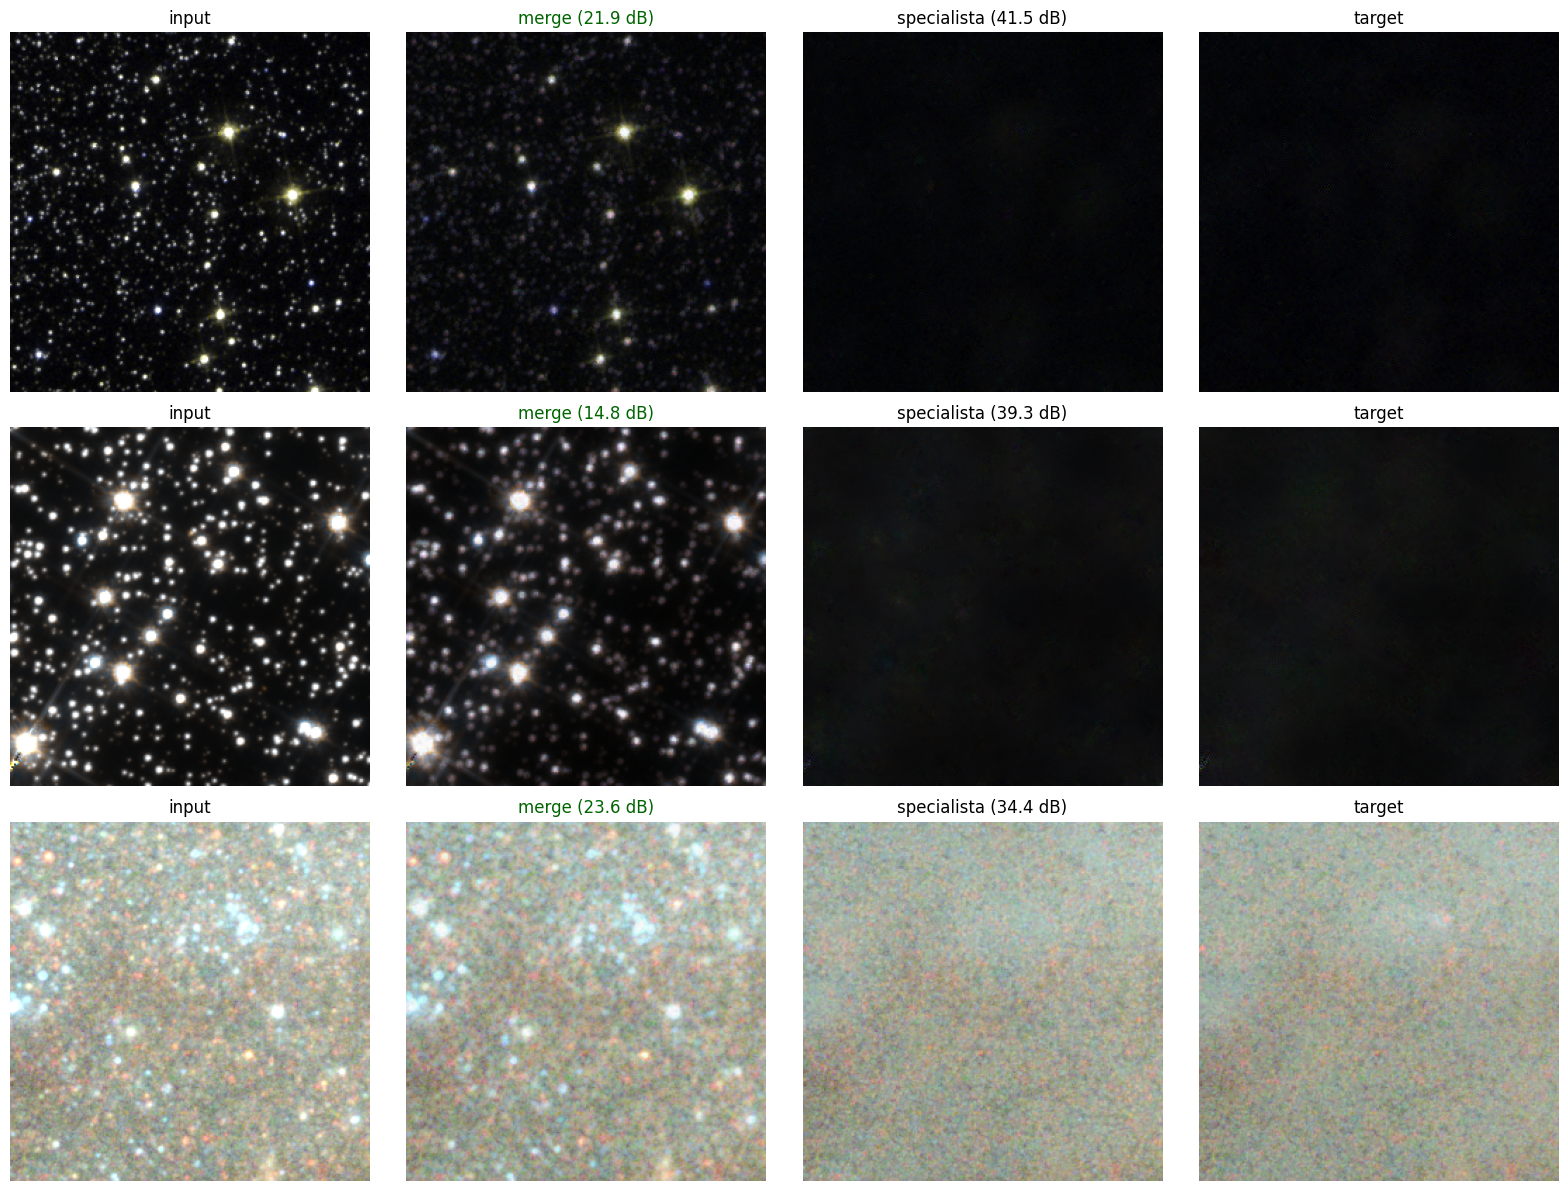

In [27]:
# ==============================================================================
# CELLA 6 - VISUALIZZAZIONE (input | merge | specialista | target) sui val split
# ==============================================================================
# Usa gli STESSI validation split della search.
# Mostra anche lo specialista come riferimento visivo del massimo raggiungibile.
import matplotlib.pyplot as plt

VIZ_TASK = "star_removal"     # "star_removal" | "restoration" | "super_resolution"
VIZ_N = 3
VIZ_DDIM_STEPS = 50

viz_model = build_model(n_steps=N_STEPS, base_channels=BASE_CHANNELS, device=DEVICE)
viz_model.load_state_dict(torch.load(PATH_OUTPUT, map_location=DEVICE))
viz_model.eval()

b = val_batches[VIZ_TASK]
n = min(VIZ_N, b["cond"].shape[0])
cond, target, x_T = b["cond"][:n], b["target"][:n], b["x_T"][:n]

with torch.no_grad():
    pred_merge = sample_ddim(viz_model, cond, ddim_steps=VIZ_DDIM_STEPS, x_T=x_T, batch_size=EVAL_BATCH_SIZE)
# specialista di riferimento
spec = normalize_to_unet(extract_state_dict(TASK_PATHS[VIZ_TASK], prefer_ema=USE_EMA),
                         [n_ for n_, _ in viz_model.network.named_parameters()])
load_unet_inplace(viz_model, spec)
with torch.no_grad():
    pred_spec = sample_ddim(viz_model, cond, ddim_steps=VIZ_DDIM_STEPS, x_T=x_T, batch_size=EVAL_BATCH_SIZE)

def to01(t, i): return ((t[i] + 1) / 2).clamp(0, 1).cpu().permute(1, 2, 0).numpy()
def psnr1(p, i): 
    a = ((p[i] + 1) / 2).clamp(0, 1); tg = ((target[i] + 1) / 2).clamp(0, 1)
    return 10 * torch.log10(1.0 / ((a - tg) ** 2).mean().clamp(min=1e-10))

fig, ax = plt.subplots(n, 4, figsize=(16, 4 * n))
if n == 1: ax = ax[None, :]
for i in range(n):
    ax[i][0].imshow(to01(cond, i)); ax[i][0].set_title("input"); ax[i][0].axis("off")
    ax[i][1].imshow(to01(pred_merge, i)); ax[i][1].set_title(f"merge ({psnr1(pred_merge,i):.1f} dB)", color="darkgreen"); ax[i][1].axis("off")
    ax[i][2].imshow(to01(pred_spec, i)); ax[i][2].set_title(f"specialista ({psnr1(pred_spec,i):.1f} dB)"); ax[i][2].axis("off")
    ax[i][3].imshow(to01(target, i)); ax[i][3].set_title("target"); ax[i][3].axis("off")
plt.tight_layout(); plt.show()
